In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import calculations as calc

# 1. Предположим, что 
- у нас есть доступ к ГС значения в которой распределяются нормально;
- у нас есть возможность многократно брать выборки из ГС;
- у нас есть возможность исследовать выборочные средние;

{'Mu': 23.942216898008112, 'Sigma^2': 3.9102875842432727, 'Sigma': 1.9774447107930155}


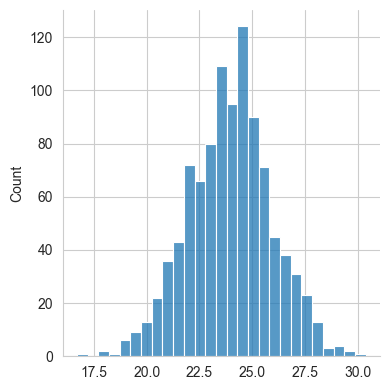

In [88]:
rng = np.random.default_rng(seed=42)
population_norm = rng.normal(size=1000, loc=24, scale=2)
print(calc.get_metrics(population_norm))
sns.displot(population_norm, height=4);

Возьмем __случайным__ образом из ГС __20__ выборок по __2__ измерения в каждой. Посчитаем среднее в каждой выборке и визуализируем получившееся распределение выборочных средних. Сделаем это три раза, чтобы посмотреть на получающиеся распределения. 

In [102]:
def get_random_sample(population, sample_size, sample_count, sample_replace, repeat=3):
    """
    
    population: Генеральная совокупность
    sample_size: Размер выборки
    sample_count: Количество выборок в эксперименте
    sample_replace: Выборки с повторением или нет
    repeat: Количество графиков на выходе, хардкод)
    """

    choice = lambda x: np.random.choice(x, size=sample_size, replace=sample_replace)
    values = []
    means = []
    for i in range(repeat):
        sample_means = [np.mean(choice(population)) for _ in range(sample_count)]
        values += sample_means
        means.append(np.mean(sample_means))

    data = pd.DataFrame({
        "value": values,
        "sample":
            [f"sample_{i + 1} (cnt={sample_count}, mean={mean:.2f})" for i, mean in enumerate(means) for _ in range(sample_count)]
    })

    # Визуализируем 
    sns.displot(data=data, x="value", col="sample", height=4);
    # return data

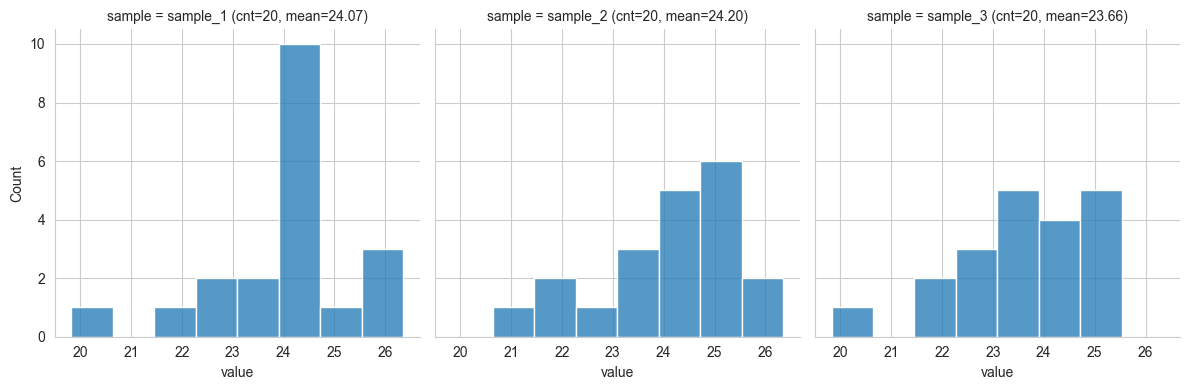

In [103]:
get_random_sample(population=population_norm, sample_size=2, sample_count=20, sample_replace=False)

Пока ничего однозначного не происходит. Увеличим количество выборок до 100, а все остальные параметры оставим без изменений. 

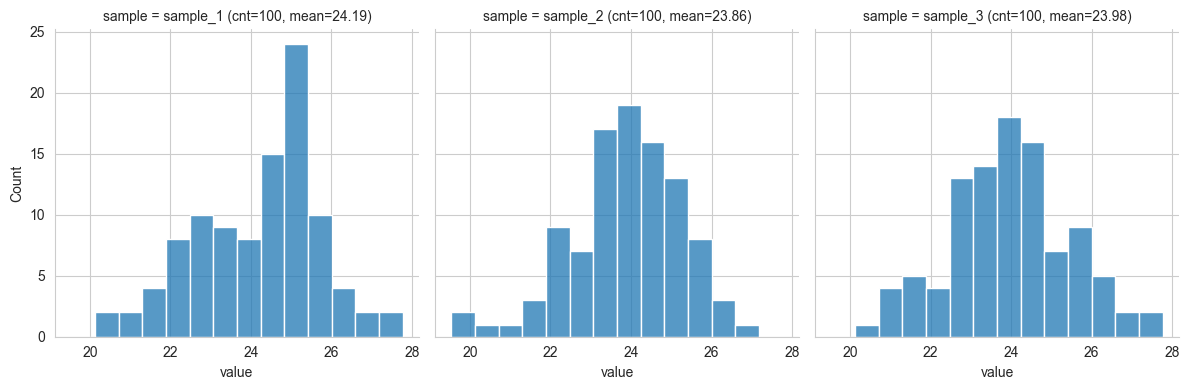

In [104]:
get_random_sample(population=population_norm, sample_size=2, sample_count=100, sample_replace=False)

С увеличением числа выборок выборочные средние как будто стремяться принять вид Нормального распределения. Увеличим количество выборок до 50 000 оставив остальные параметры без изменений. 

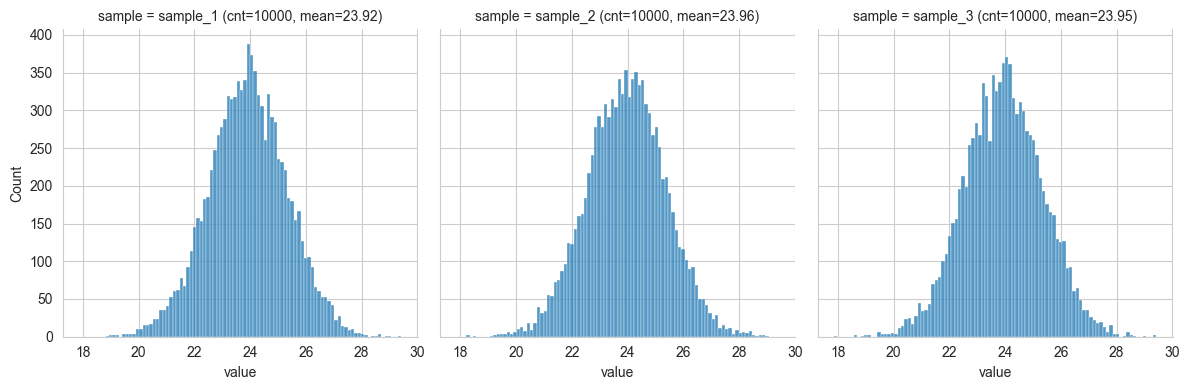

In [106]:
get_random_sample(population=population_norm, sample_size=2, sample_count=10_000, sample_replace=False)

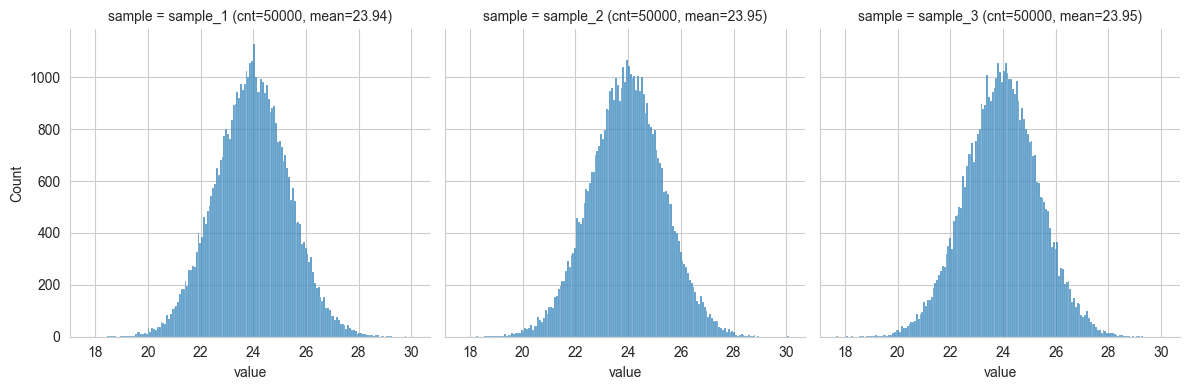

In [107]:
get_random_sample(population=population_norm, sample_size=2, sample_count=50_000, sample_replace=False)

Вау! С увеличением числа выборок выборочные средние действительно принимаю форму Нормального распределения.
  А еще и __среднее выборочных средних__ приблизилось к среднему ГС, которе мы установили при ее генерации. Получается, что $Mean(\bar{X})=\mu$ и это несмещенная оценка (статистика). 

# 2. А что если ГС распределяется не по Нормальному распределению?

{'Mu': 1.014358100001555, 'Sigma^2': 1.0549166626613515, 'Sigma': 1.027091360425815}


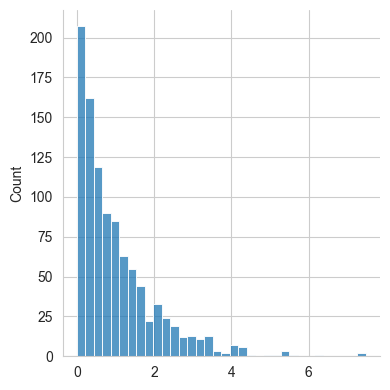

In [108]:
rng = np.random.default_rng(seed=42)
population_exp = rng.exponential(scale=1, size=1000)
print(calc.get_metrics(population_exp))
sns.displot(population_exp, height=4);

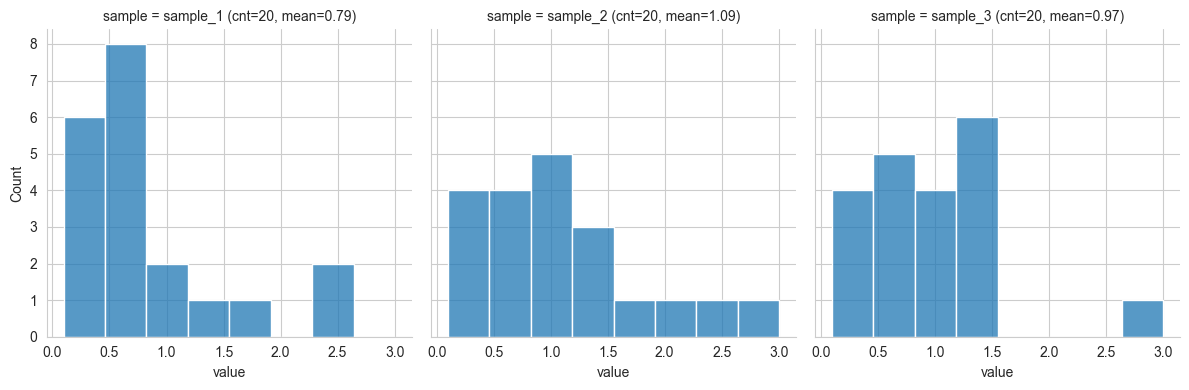

In [109]:
get_random_sample(population=population_exp, sample_size=2, sample_count=20, sample_replace=False)

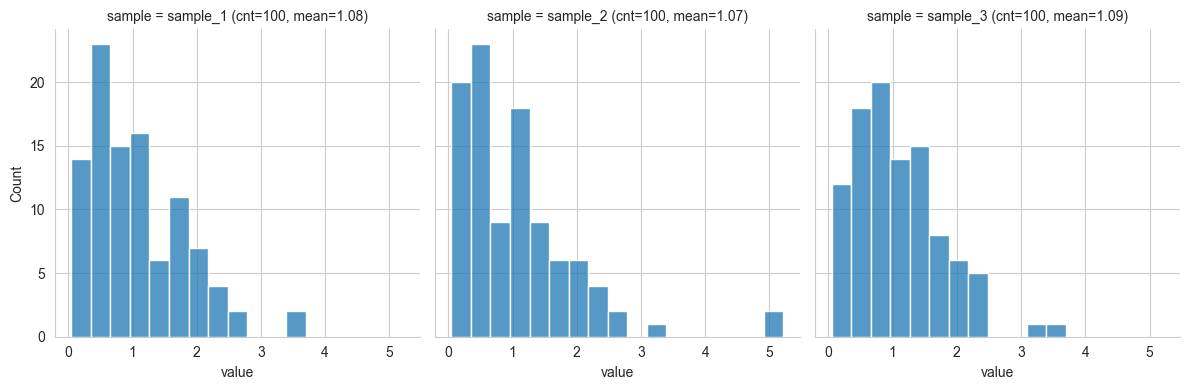

In [110]:
get_random_sample(population=population_exp, sample_size=2, sample_count=100, sample_replace=False)

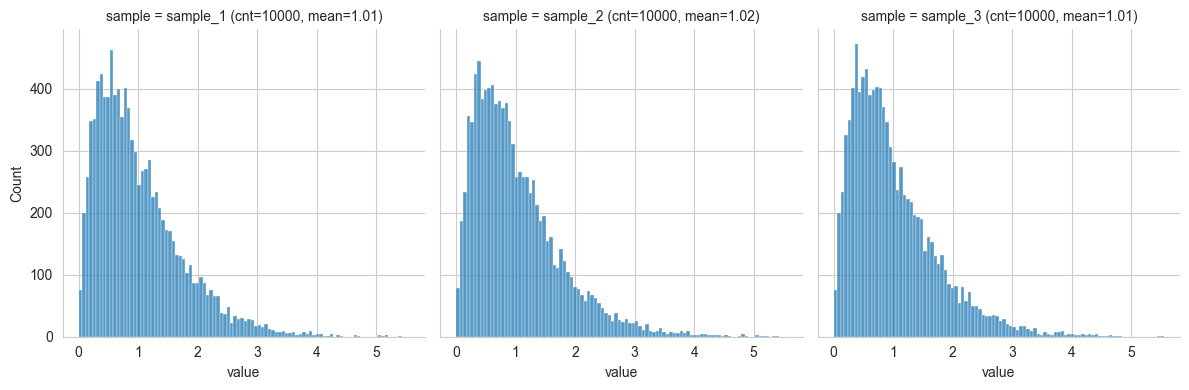

In [111]:
get_random_sample(population=population_exp, sample_size=2, sample_count=10_000, sample_replace=False)

Что-то как-то не хочет распределение выборочных средний превращаться в среднее. Увеличим количество значений в выборках.

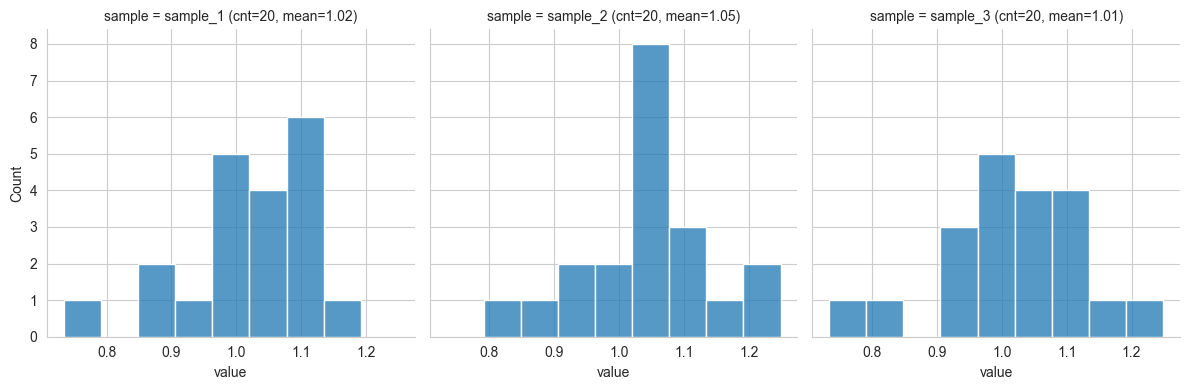

In [115]:
get_random_sample(population=population_exp, sample_size=100, sample_count=20, sample_replace=False)

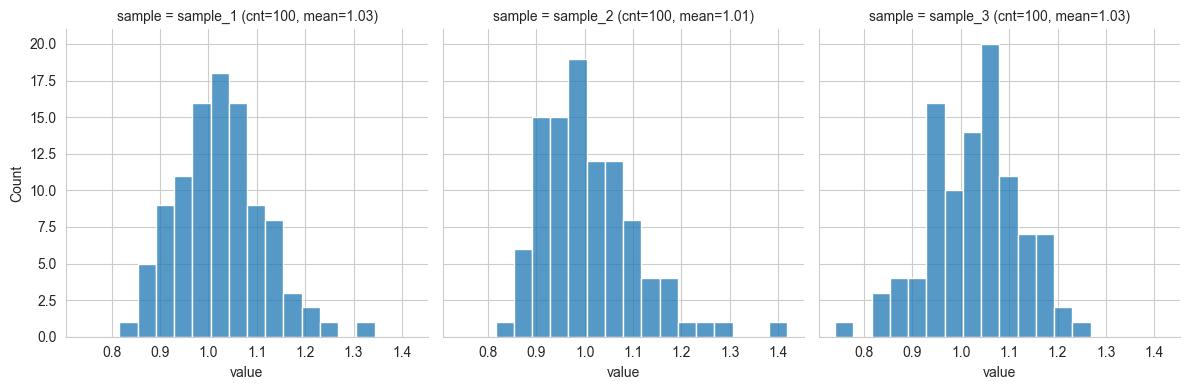

In [116]:
get_random_sample(population=population_exp, sample_size=100, sample_count=100, sample_replace=False)

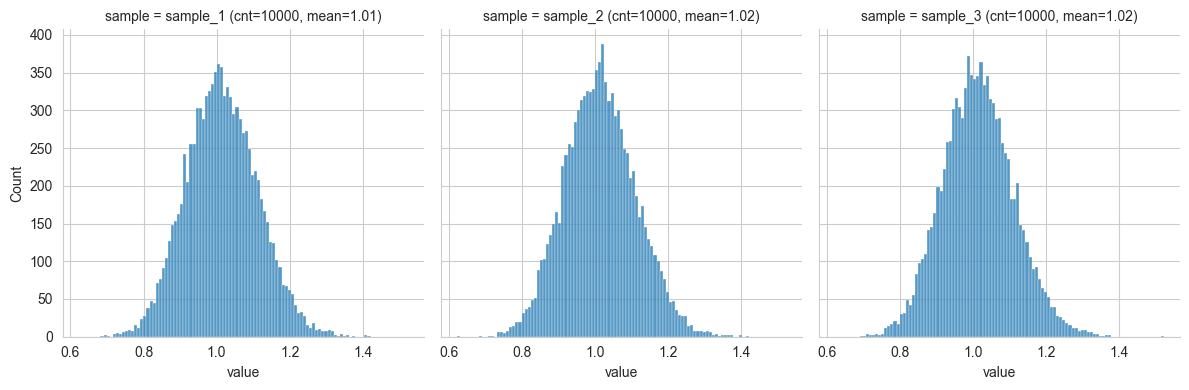

In [117]:
get_random_sample(population=population_exp, sample_size=100, sample_count=10_000, sample_replace=False)

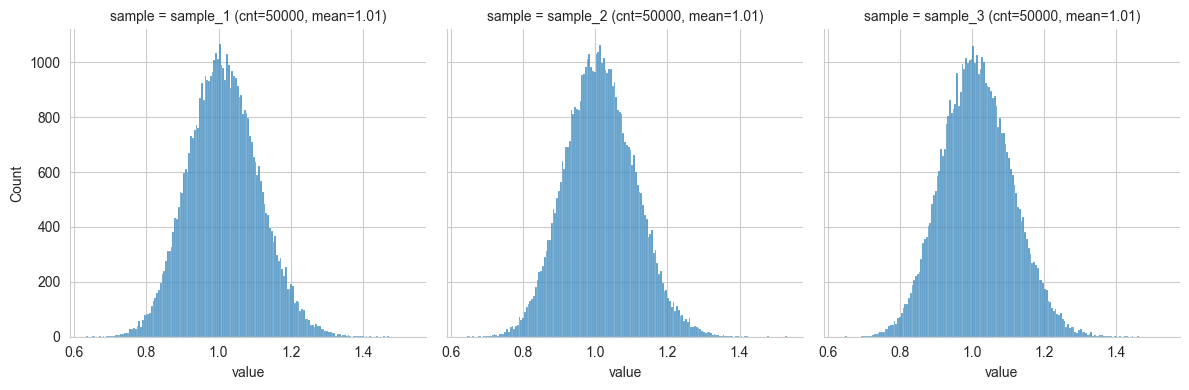

In [118]:
get_random_sample(population=population_exp, sample_size=100, sample_count=50_000, sample_replace=False)